# IS4487 Week 5 - Practice Code

This notebook is designed to help you follow along with the **Week 5 Lecture and Reading**

The practice code demos are intended to give you a chance to see working code and can be a source for your lap and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Univariate analysis
- Multi-variate analysis



### Context: Automotive Performance Trends

As an analyst for an automotive consultancy, you are investigating how vehicle performance has shifted over different launch years. Your task is to explore the data to understand the distribution of efficiency and how horsepower relates to fuel economy.

# Step 1: Install and Import all Necessary libraries

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load Dataset (replace with your own file if needed)

In [32]:
# Read the extended_mtcars.xlsx file into a new DataFrame named mtcars2
df = pd.read_excel('extended_mtcars.xlsx')


# Step 3: Preview and Basic Info

In [33]:
print(df.head())

            car_name   mpg  cyl   disp  ...  gear  carb  car_id  year
0          Mazda RX4  21.0    6  160.0  ...     4     4       0  2000
1      Mazda RX4 Wag  21.0    6  160.0  ...     4     4       1  2000
2         Datsun 710  22.8    4  108.0  ...     4     1       2  2000
3     Hornet 4 Drive  21.4    6  258.0  ...     3     1       3  2000
4  Hornet Sportabout  18.7    8  360.0  ...     3     2       4  2000

[5 rows x 14 columns]


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   car_name  96 non-null     object 
 1   mpg       96 non-null     float64
 2   cyl       96 non-null     int64  
 3   disp      96 non-null     float64
 4   hp        96 non-null     int64  
 5   drat      96 non-null     float64
 6   wt        96 non-null     float64
 7   qsec      95 non-null     float64
 8   vs        96 non-null     int64  
 9   am        96 non-null     int64  
 10  gear      96 non-null     int64  
 11  carb      96 non-null     int64  
 12  car_id    96 non-null     int64  
 13  year      96 non-null     int64  
dtypes: float64(5), int64(8), object(1)
memory usage: 10.6+ KB


In [35]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,car_id,year
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,95.000000,96.000000,96.00000,96.000000,96.000000,96.000000,96.000000
mean,19.932292,6.104167,227.555208,145.125000,3.563750,3.181469,17.854526,0.437500,0.40625,3.687500,2.812500,15.500000,2001.000000
std,6.287372,1.866487,124.623839,69.468092,0.642523,1.021952,1.776502,0.498682,0.49371,0.729996,1.598107,9.281561,0.820783
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.500000,0.000000,0.00000,3.000000,1.000000,0.000000,2000.000000
25%,15.425000,4.000000,120.300000,95.000000,3.080000,2.465000,16.885000,0.000000,0.00000,3.000000,2.000000,7.750000,2000.000000
50%,19.200000,6.000000,167.600000,123.000000,3.695000,3.215000,17.820000,0.000000,0.00000,4.000000,2.000000,15.500000,2001.000000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.00000,4.000000,4.000000,23.250000,2002.000000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.00000,5.000000,8.000000,31.000000,2002.000000


# Step 4: Check for Missing Values

In [36]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
car_name    0
mpg         0
cyl         0
disp        0
hp          0
drat        0
wt          0
qsec        1
vs          0
am          0
gear        0
carb        0
car_id      0
year        0
dtype: int64


# Step 5: Univariate Visualization

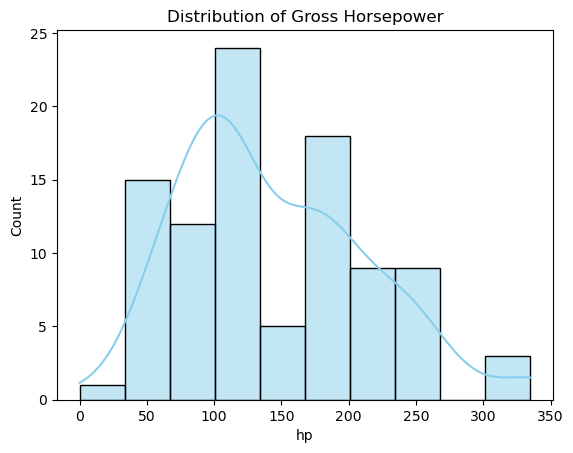

In [37]:
# Distribution of Horsepower
sns.histplot(df['hp'], kde=True, color='skyblue')
plt.title("Distribution of Gross Horsepower")
plt.show()


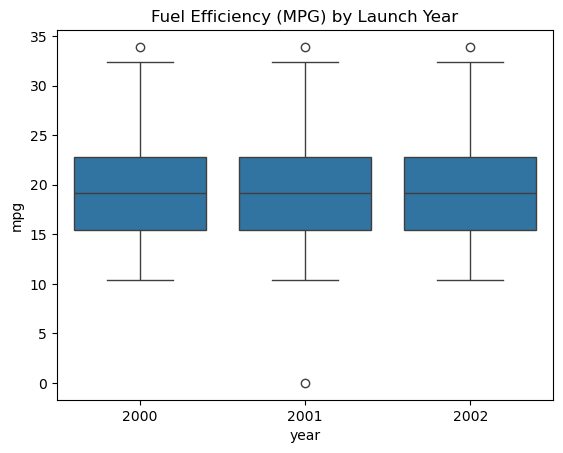

In [38]:

# Efficiency by Year
sns.boxplot(x='year', y='mpg', data=df)
plt.title("Fuel Efficiency (MPG) by Launch Year")
plt.show()

# Step 6: Bivariate Visualization

In [39]:
# Correlation between MPG and HP
correlation = df[['mpg', 'hp']].corr()
print("\nCorrelation Matrix:")
print(correlation)



Correlation Matrix:
          mpg        hp
mpg  1.000000 -0.648022
hp  -0.648022  1.000000


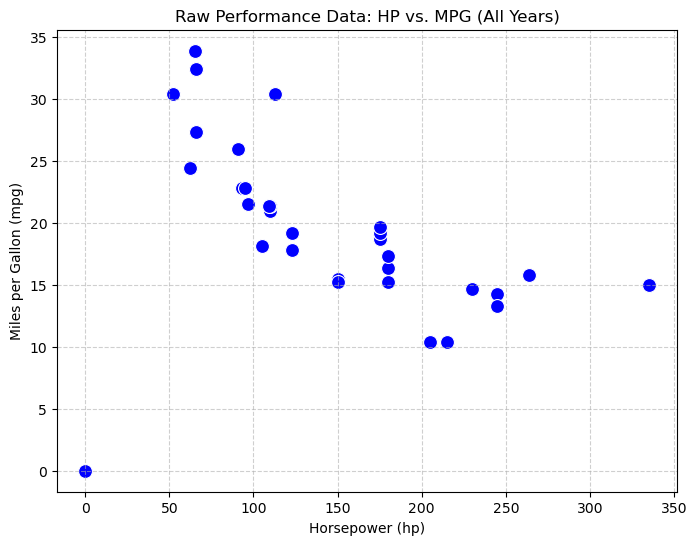

In [44]:
# Scatterplot: All HP vs All MPG
plt.figure(figsize=(8,6))
sns.scatterplot(x='hp', y='mpg', data=df, s=100, color='blue')
plt.title("Raw Performance Data: HP vs. MPG (All Years)")
plt.xlabel("Horsepower (hp)")
plt.ylabel("Miles per Gallon (mpg)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### The "Year" Effect: Multiplot (Faceting)
To account for the "duplicate" car entries, we split the data by year. This allows us to see if the relationship between power and efficiency shifted between 2000 and 2002.

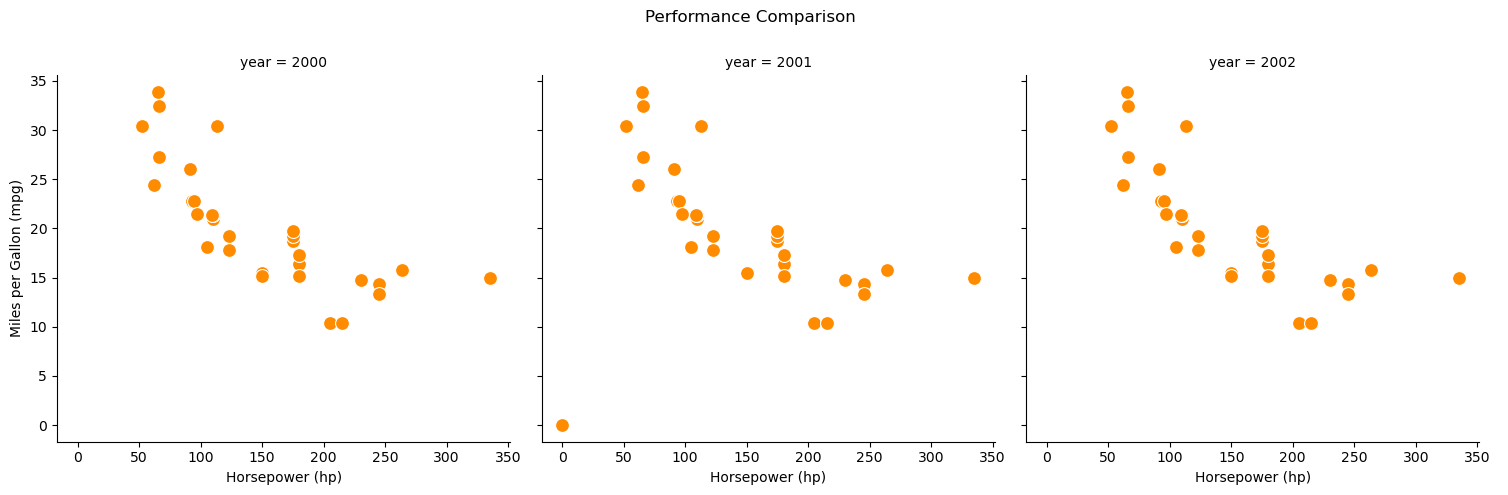

In [46]:
# Multiplot (FacetGrid) by Year
g = sns.FacetGrid(df, col="year", height=5, aspect=1)
g.map(sns.scatterplot, "hp", "mpg", s=100, color='darkorange')
g.add_legend()
g.set_axis_labels("Horsepower (hp)", "Miles per Gallon (mpg)")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Performance Comparison')
plt.show()

### Notice the outlier in 2001? How do you deal with this?

### Aggregated Summary: Averge HP by Car Model

Finally, we simplify the data. Instead of looking at every year, we look at the "typical" power output for each car name across the entire dataset.

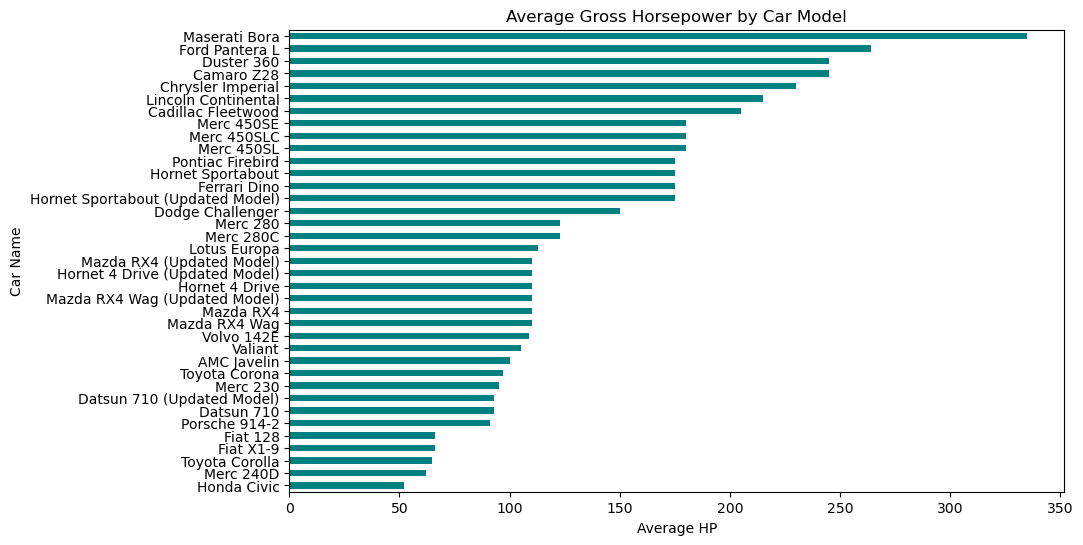

In [49]:
# Calculating Average HP per Car
avg_hp_per_car = df.groupby("car_name")["hp"].mean().sort_values()

# Plotting Average HP
plt.figure(figsize=(10,6))
avg_hp_per_car.plot(kind='barh', color='teal')
plt.title("Average Gross Horsepower by Car Model")
plt.xlabel("Average HP")
plt.ylabel("Car Name")
plt.show()

#### Bonus Plot


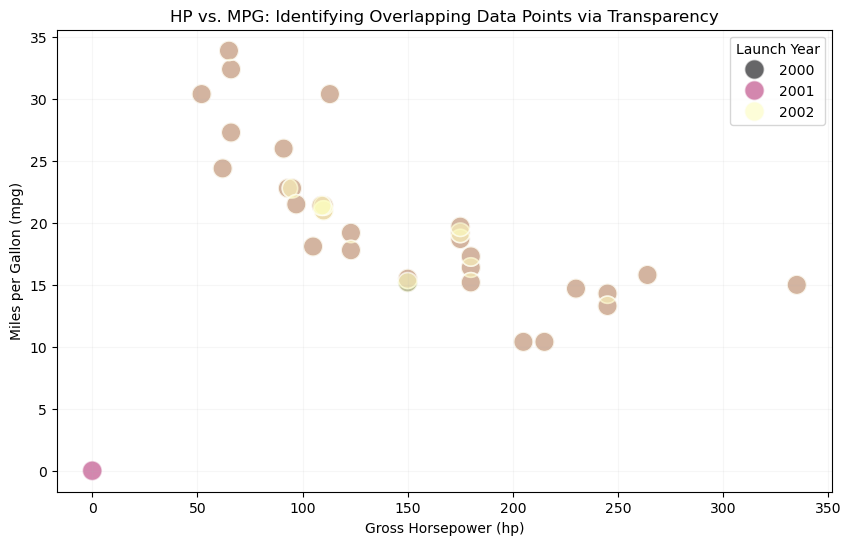

In [53]:
# Scatterplot: HP vs MPG with Transparency
plt.figure(figsize=(10,6))

# alpha=0.6 makes the points semi-transparent
# s=200 makes the points larger to emphasize the color blending
sns.scatterplot(
    x='hp', 
    y='mpg', 
    hue='year', 
    data=df, 
    s=200, 
    palette='magma', 
    alpha=0.6, 
    edgecolor='w' # Adds a white edge to help distinguish overlapping circles
)

plt.title("HP vs. MPG: Identifying Overlapping Data Points via Transparency")
plt.xlabel("Gross Horsepower (hp)")
plt.ylabel("Miles per Gallon (mpg)")
plt.legend(title="Launch Year")
plt.grid(True, alpha=0.1)

plt.show()

# Step 7: Outlier Detection using IQR

In [54]:
Q1 = df['wt'].quantile(0.25)
Q3 = df['wt'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['wt'] < Q1 - 1.5 * IQR) | (df['wt'] > Q3 + 1.5 * IQR)]
print(f"\nNumber of Weight Outliers: {len(outliers)}")


Number of Weight Outliers: 7


# Step 8: Ethical Reflection Prompt

In [43]:
print("\nReflection: In the context of automotive data, if we use this data to predict future fuel taxes, what are the risks of ignoring 'Year' or 'Engine Type'? How might biased data (e.g., only including luxury cars) lead to unfair policy decisions?")


Reflection: In the context of automotive data, if we use this data to predict future fuel taxes, what are the risks of ignoring 'Year' or 'Engine Type'? How might biased data (e.g., only including luxury cars) lead to unfair policy decisions?
